In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_raw = pd.read_excel("satisfaction.xlsx")
df = pd.read_csv("passenger_satisfaction_cleaned.csv")
print("===== BEFORE CLEANING =====")
print(f"Shape: {df_raw.shape}")
print(f"\nMissing values:")
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")
print(f"\nData types:\n{df_raw.dtypes.value_counts()}")

print("===== AFTER CLEANING =====")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

===== BEFORE CLEANING =====
Shape: (129880, 24)

Missing values:
Arrival Delay in Minutes    393
dtype: int64

Duplicate rows: 0

Data types:
int64      18
object      5
float64     1
Name: count, dtype: int64
===== AFTER CLEANING =====
Shape: (129880, 24)

Data types:
int64      19
object      4
float64     1
Name: count, dtype: int64


In [31]:
df = df_raw.copy()
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
 
missing_before = (df.isnull().sum() / len(df)) * 100
missing_before_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_before
}).sort_values(by="missing_percent", ascending=False)
 
print("\n===== Missing Values (BEFORE cleaning) =====")
print(missing_before_df[missing_before_df["missing_count"] > 0])
 
if "Arrival Delay in Minutes" in df.columns:
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
        df["Arrival Delay in Minutes"].median()
    )
 
df = df.drop_duplicates()
 
if "Age" in df.columns:
    df = df[df["Age"] > 0]
if "Departure Delay in Minutes" in df.columns:
    df = df[df["Departure Delay in Minutes"] >= 0]
if "Arrival Delay in Minutes" in df.columns:
    df = df[df["Arrival Delay in Minutes"] >= 0]
 
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")
 
if "satisfaction_v2" in df.columns:
    df = df.rename(columns={"satisfaction_v2": "satisfaction"})
 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
 
if "satisfaction" in df.columns:
    df["satisfaction"] = df["satisfaction"].map({
        "neutral or dissatisfied": 0,
        "satisfied": 1
    })
 
missing_after = (df.isnull().sum() / len(df)) * 100
missing_after_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_after
}).sort_values(by="missing_percent", ascending=False)
 
print("\n===== Missing Values (AFTER cleaning) =====")
print(missing_after_df[missing_after_df["missing_count"] > 0])
 
if "id" in df.columns:
    df = df.sort_values(by="id", ascending=True)
 
output_file = "passenger_satisfaction_cleaned.csv"
df.to_csv(output_file, index=False)
print(f"\nCleaned file exported: {output_file}")
print("Final shape:", df.shape)
 


===== Missing Values (BEFORE cleaning) =====
                          missing_count  missing_percent
Arrival Delay in Minutes            393         0.302587

===== Missing Values (AFTER cleaning) =====
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Cleaned file exported: passenger_satisfaction_cleaned.csv
Final shape: (129880, 24)


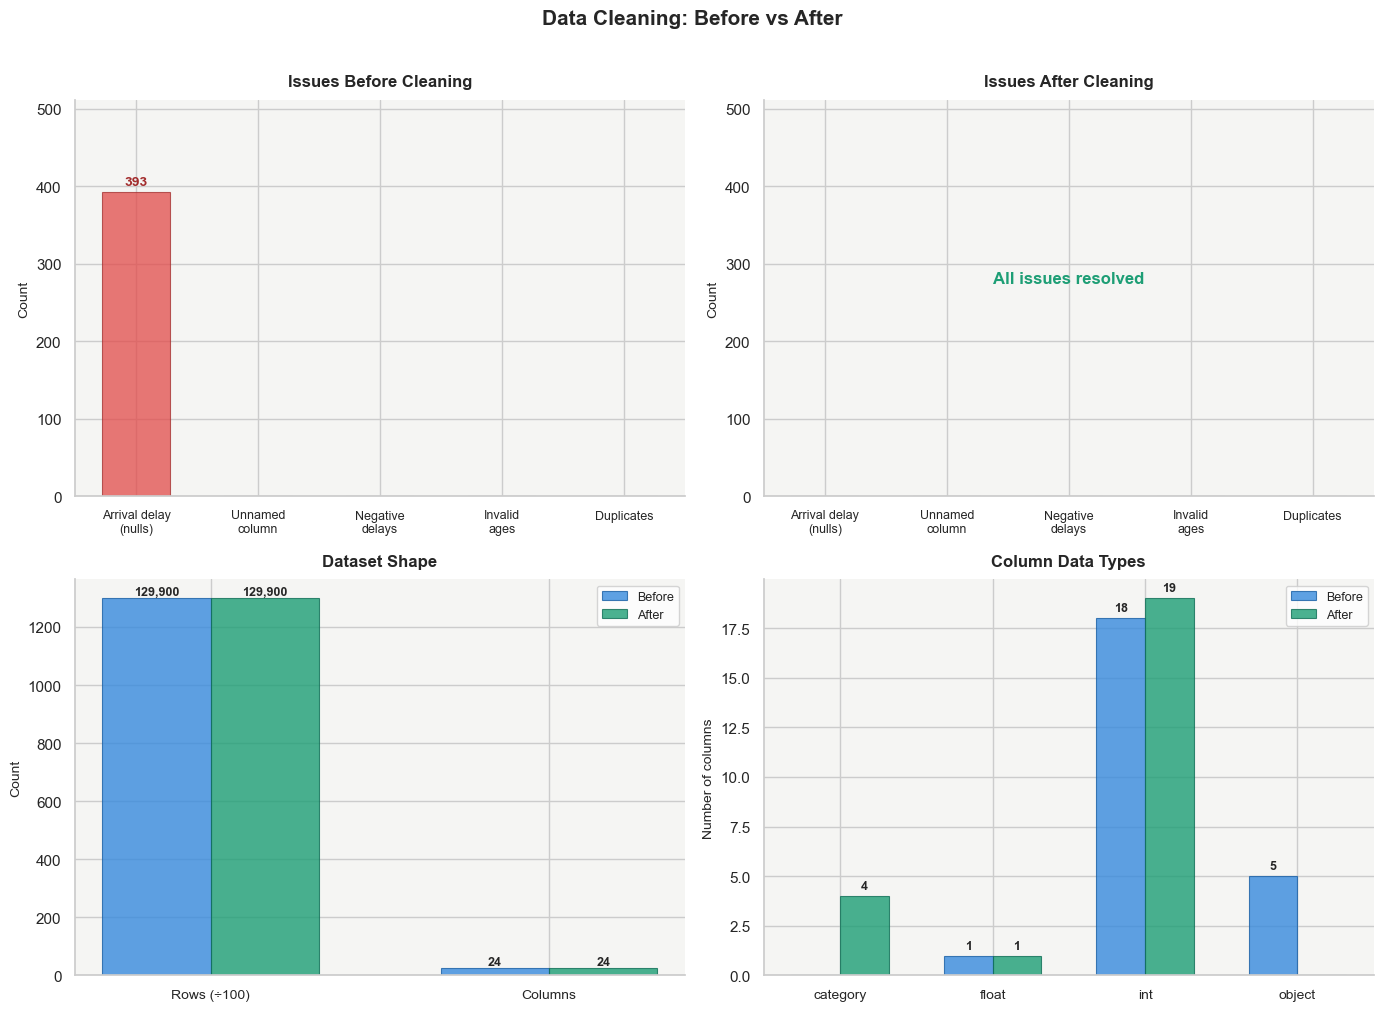

In [33]:
BLUE   = "#378ADD"
GREEN  = "#1D9E75"
RED    = "#E24B4A"
LGRAY  = "#f5f5f3"
DGRAY  = "#888780"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Data Cleaning: Before vs After", fontsize=15, fontweight="bold", y=1.01)
fig.patch.set_facecolor("white")

# ── Panel 1: Missing values before ──────────────────
ax1 = axes[0, 0]
issues_labels = ["Arrival delay\n(nulls)", "Unnamed\ncolumn", "Negative\ndelays", "Invalid\nages", "Duplicates"]
issues_before = [
    df_raw["Arrival Delay in Minutes"].isnull().sum() if "Arrival Delay in Minutes" in df_raw.columns else 0,
    1 if "Unnamed: 0" in df_raw.columns else 0,
    int((df_raw["Departure Delay in Minutes"] < 0).sum()) if "Departure Delay in Minutes" in df_raw.columns else 0,
    int((df_raw["Age"] <= 0).sum()) if "Age" in df_raw.columns else 0,
    df_raw.duplicated().sum()
]
bars = ax1.bar(issues_labels, issues_before, color=RED, alpha=0.75, edgecolor="#A32D2D", linewidth=0.8, width=0.55)
for bar, val in zip(bars, issues_before):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold", color="#A32D2D")
ax1.set_title("Issues Before Cleaning", fontsize=12, fontweight="bold", pad=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.set_facecolor(LGRAY)
ax1.tick_params(axis="x", labelsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_ylim(0, max(issues_before) * 1.25 + 20)

# ── Panel 2: Missing values after ───────────────────
ax2 = axes[0, 1]
issues_after = [0, 0, 0, 0, 0]
bars2 = ax2.bar(issues_labels, issues_after, color=GREEN, alpha=0.75, edgecolor="#0F6E56", linewidth=0.8, width=0.55)
ax2.set_ylim(0, max(issues_before) * 1.25 + 20)
ax2.text(0.5, 0.55, "All issues resolved", transform=ax2.transAxes,
         ha="center", va="center", fontsize=12, color=GREEN, fontweight="bold")
ax2.set_title("Issues After Cleaning", fontsize=12, fontweight="bold", pad=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_facecolor(LGRAY)
ax2.tick_params(axis="x", labelsize=9)
ax2.spines[["top", "right"]].set_visible(False)

# ── Panel 3: Dataset shape ───────────────────────────
ax3 = axes[1, 0]
x = np.arange(2)
width = 0.32
shape_labels = ["Rows (÷100)", "Columns"]
before_vals = [round(df_raw.shape[0] / 100), df_raw.shape[1]]
after_vals  = [round(df.shape[0] / 100),     df.shape[1]]

b1 = ax3.bar(x - width / 2, before_vals, width, label="Before", color=BLUE,  alpha=0.8, edgecolor="#185FA5", linewidth=0.8)
b2 = ax3.bar(x + width / 2, after_vals,  width, label="After",  color=GREEN, alpha=0.8, edgecolor="#0F6E56", linewidth=0.8)

def annotate_bars(ax, bars, multipliers):
    for bar, mult in zip(bars, multipliers):
        val = bar.get_height() * mult
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{int(val):,}" if mult > 1 else str(int(val)),
                ha="center", va="bottom", fontsize=9, fontweight="bold")

annotate_bars(ax3, b1, [100, 1])
annotate_bars(ax3, b2, [100, 1])

ax3.set_xticks(x)
ax3.set_xticklabels(shape_labels, fontsize=10)
ax3.set_title("Dataset Shape", fontsize=12, fontweight="bold", pad=10)
ax3.set_ylabel("Count", fontsize=10)
ax3.set_facecolor(LGRAY)
ax3.legend(fontsize=9)
ax3.spines[["top", "right"]].set_visible(False)

# ── Panel 4: Data types ──────────────────────────────
ax4 = axes[1, 1]
raw_dtypes  = df_raw.dtypes.value_counts()
clean_dtypes = df.dtypes.value_counts()

dtype_map = {
    "int64":    "int",
    "float64":  "float",
    "object":   "object",
    "category": "category",
    "int32":    "int",
}

def aggregate_dtypes(dtype_series):
    out = {}
    for k, v in dtype_series.items():
        label = dtype_map.get(str(k), str(k))
        out[label] = out.get(label, 0) + v
    return out

before_dtype = aggregate_dtypes(raw_dtypes)
after_dtype  = aggregate_dtypes(clean_dtypes)
all_labels   = sorted(set(before_dtype) | set(after_dtype))

xd = np.arange(len(all_labels))
bd = [before_dtype.get(l, 0) for l in all_labels]
ad = [after_dtype.get(l, 0)  for l in all_labels]

bd1 = ax4.bar(xd - width / 2, bd, width, label="Before", color=BLUE,  alpha=0.8, edgecolor="#185FA5", linewidth=0.8)
bd2 = ax4.bar(xd + width / 2, ad, width, label="After",  color=GREEN, alpha=0.8, edgecolor="#0F6E56", linewidth=0.8)

for bar in list(bd1) + list(bd2):
    v = int(bar.get_height())
    if v > 0:
        ax4.text(bar.get_x() + bar.get_width() / 2, v + 0.2,
                 str(v), ha="center", va="bottom", fontsize=9, fontweight="bold")

ax4.set_xticks(xd)
ax4.set_xticklabels(all_labels, fontsize=10)
ax4.set_title("Column Data Types", fontsize=12, fontweight="bold", pad=10)
ax4.set_ylabel("Number of columns", fontsize=10)
ax4.set_facecolor(LGRAY)
ax4.legend(fontsize=9)
ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


Common columns to compare: 23


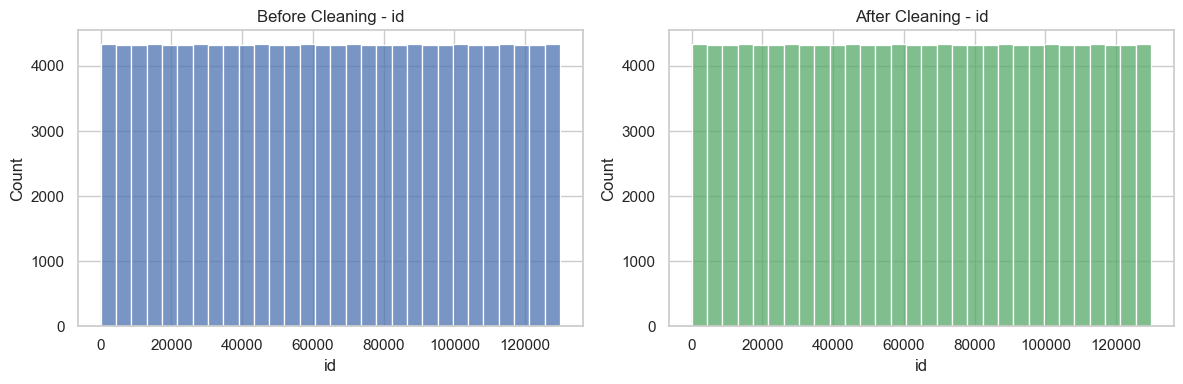

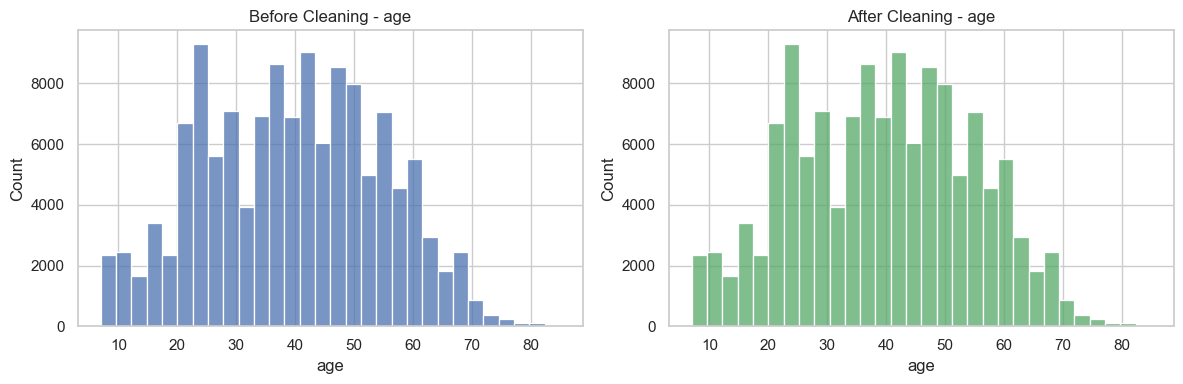

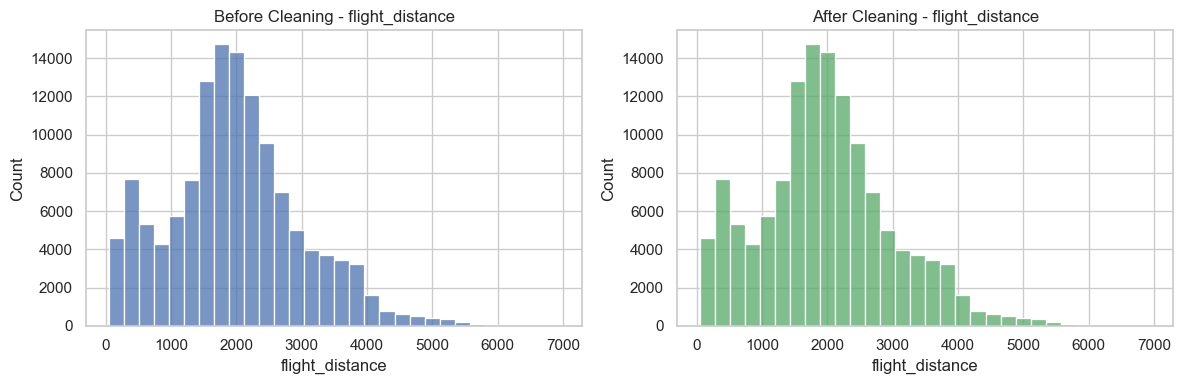

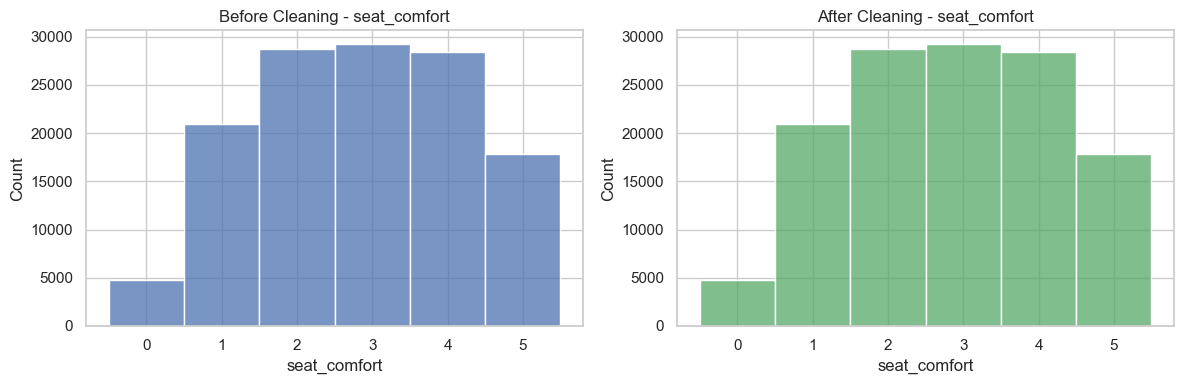

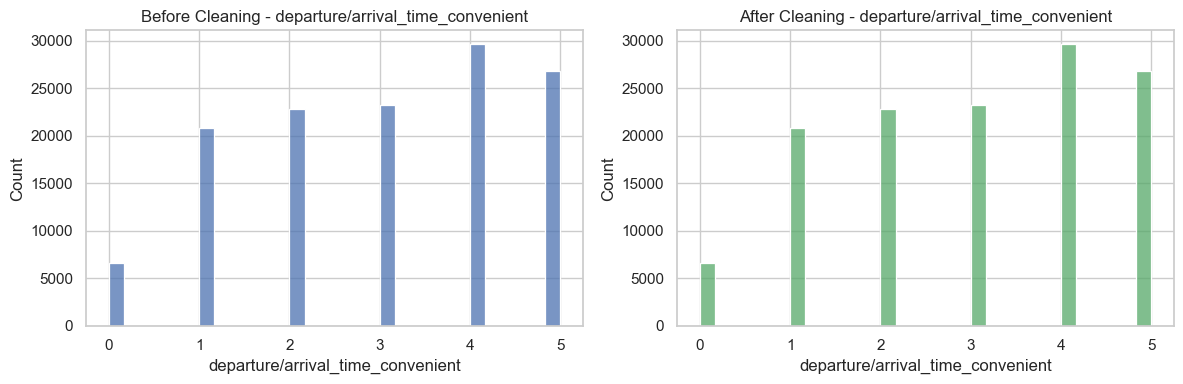

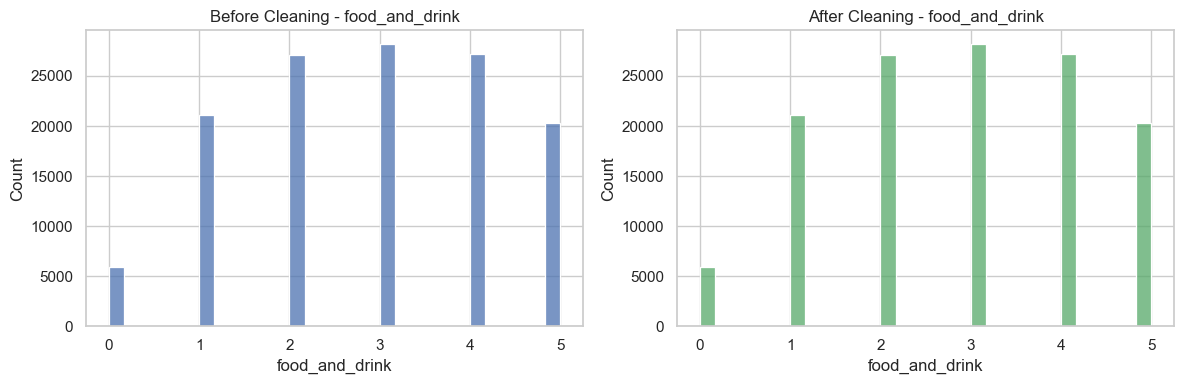

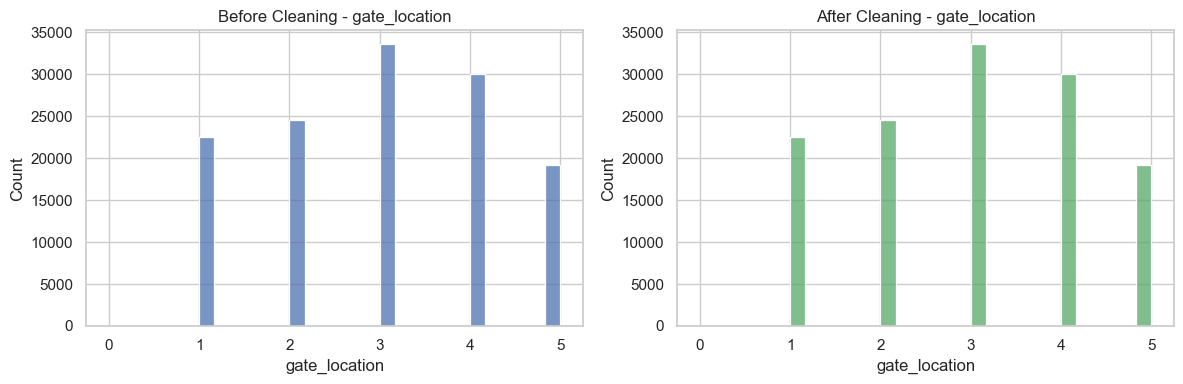

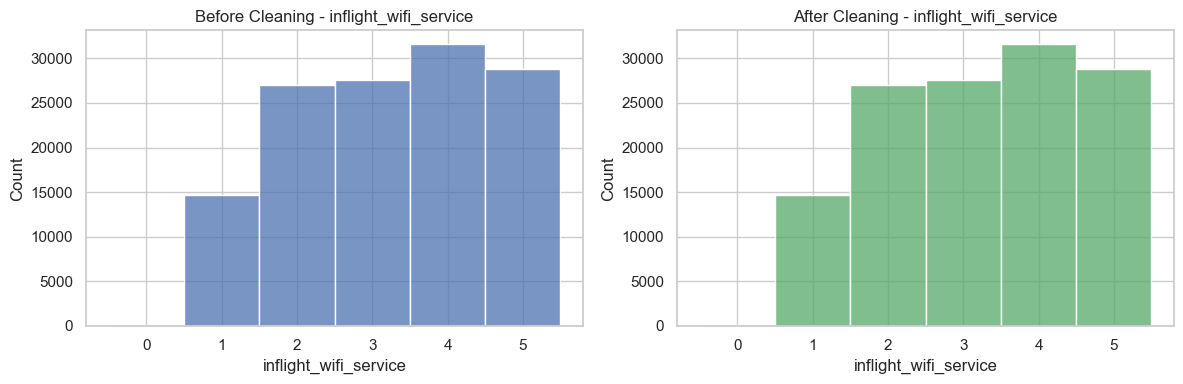

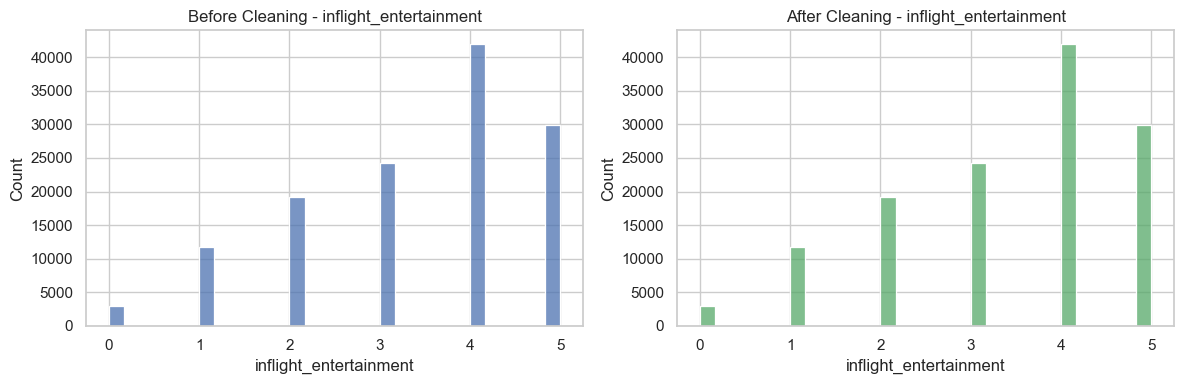

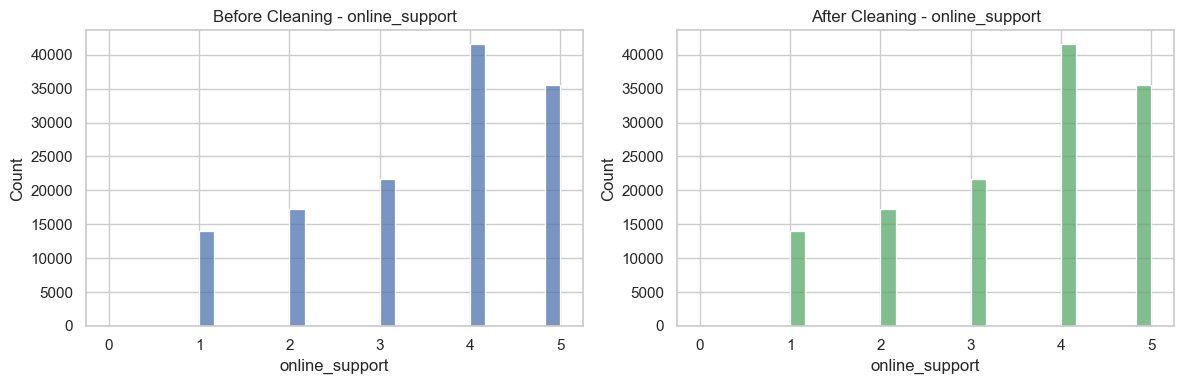

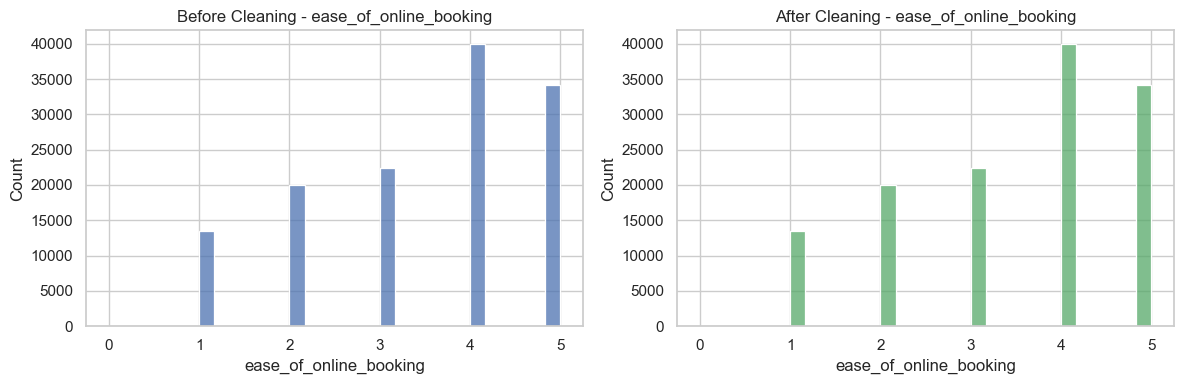

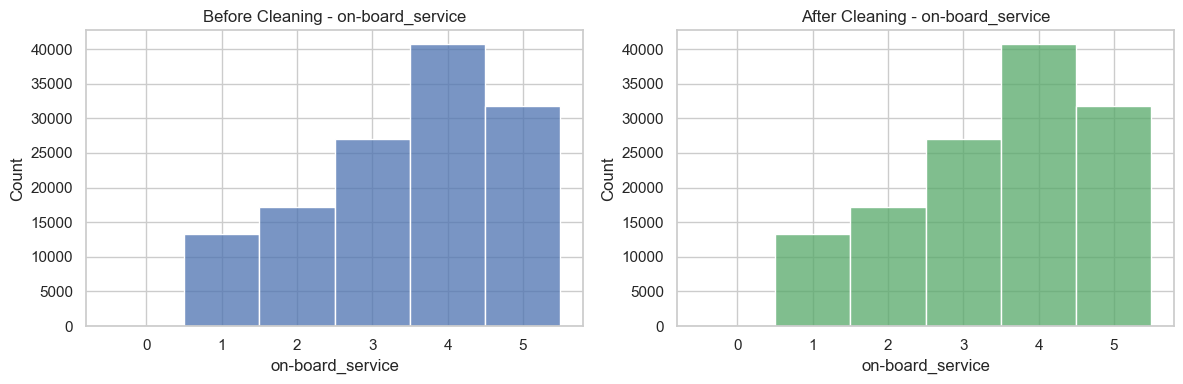

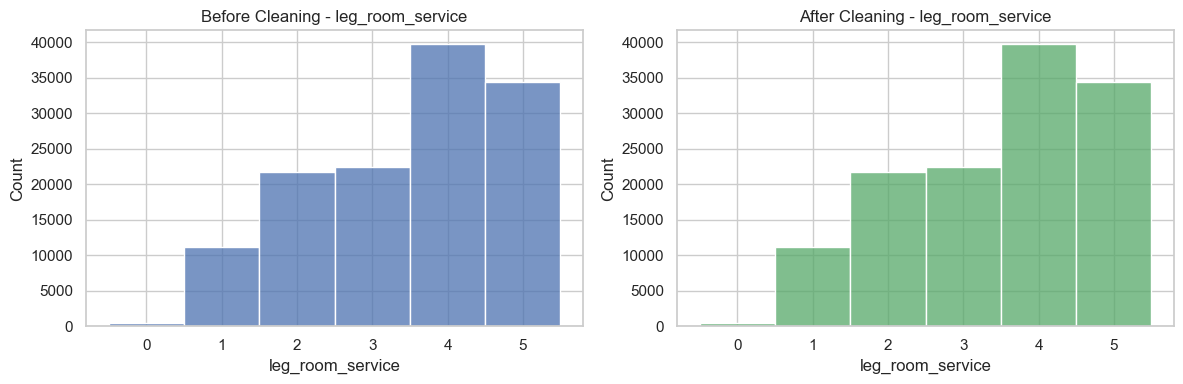

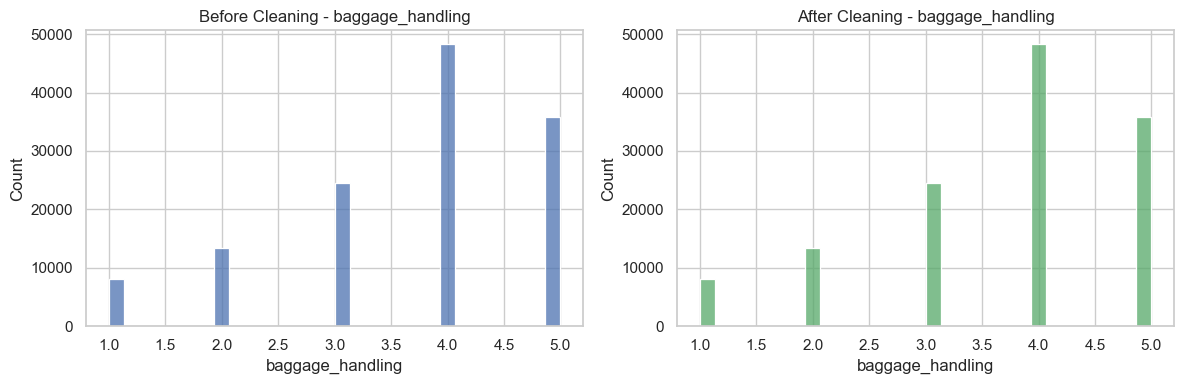

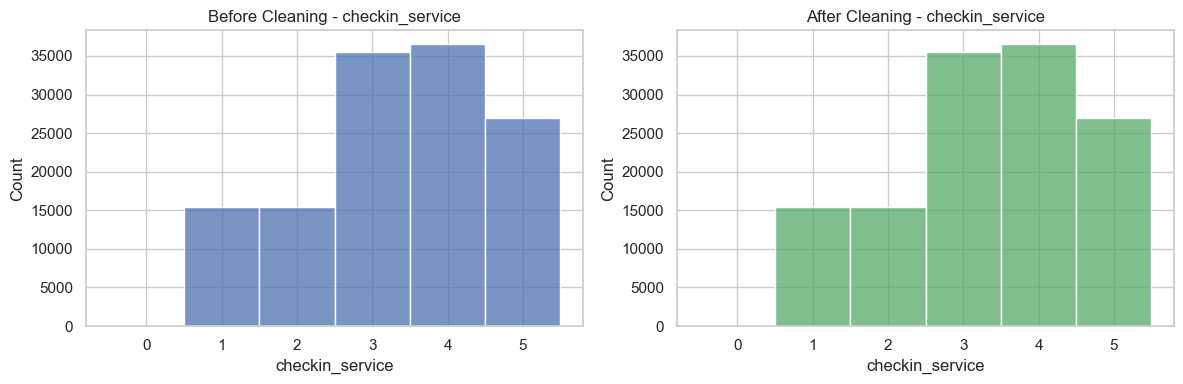

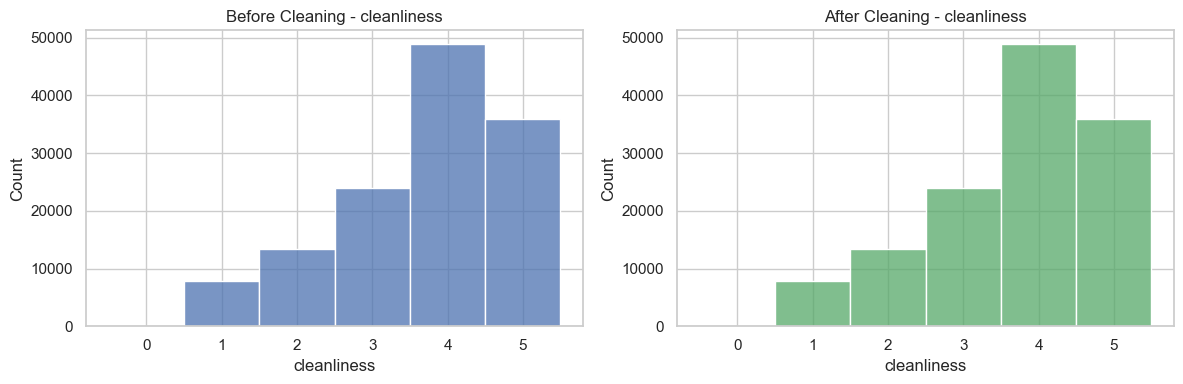

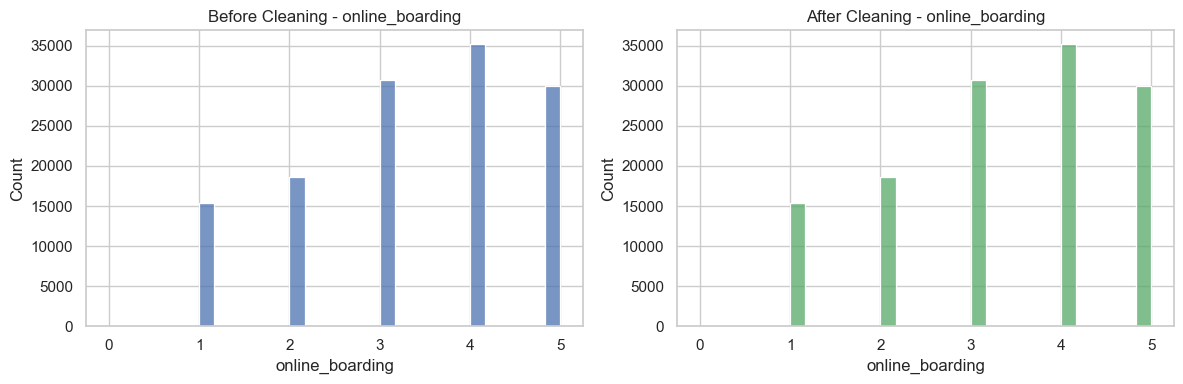

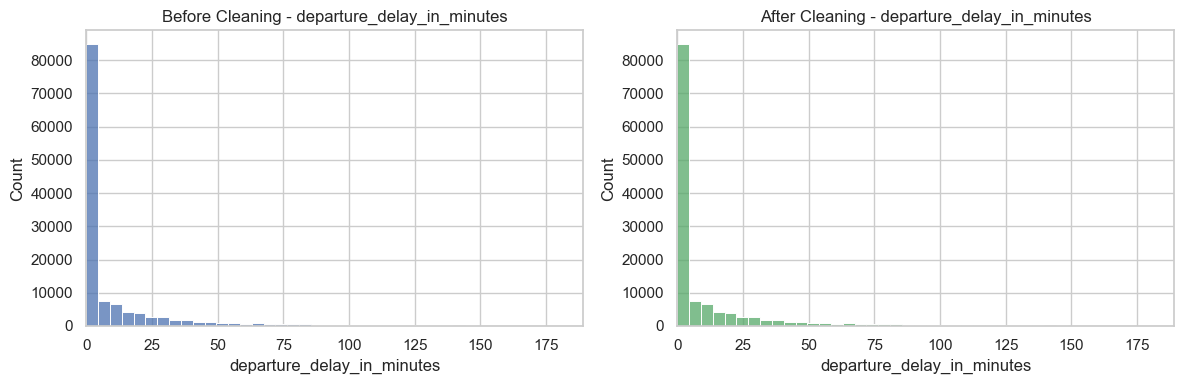

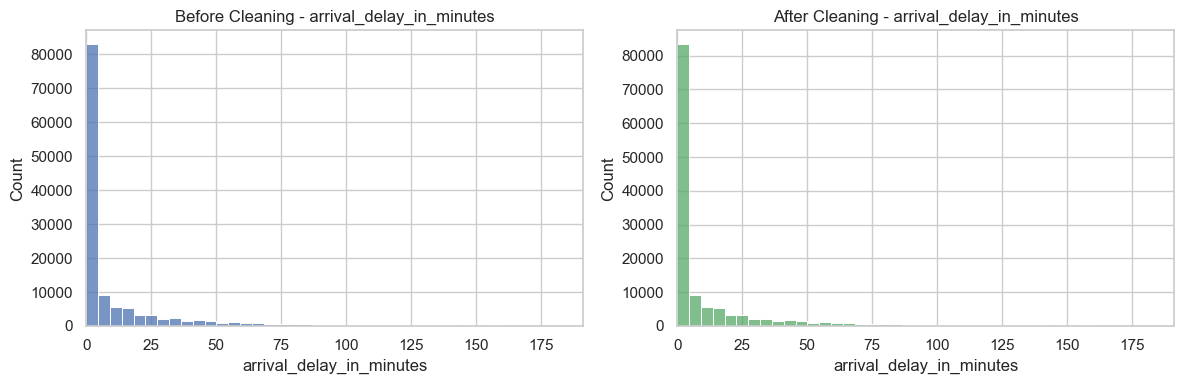

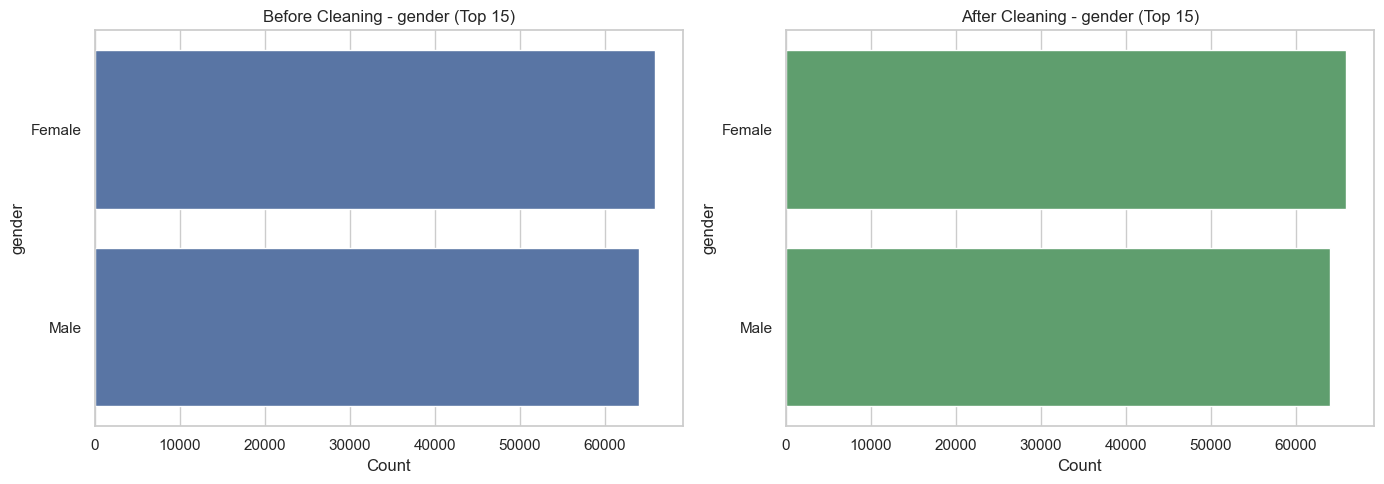

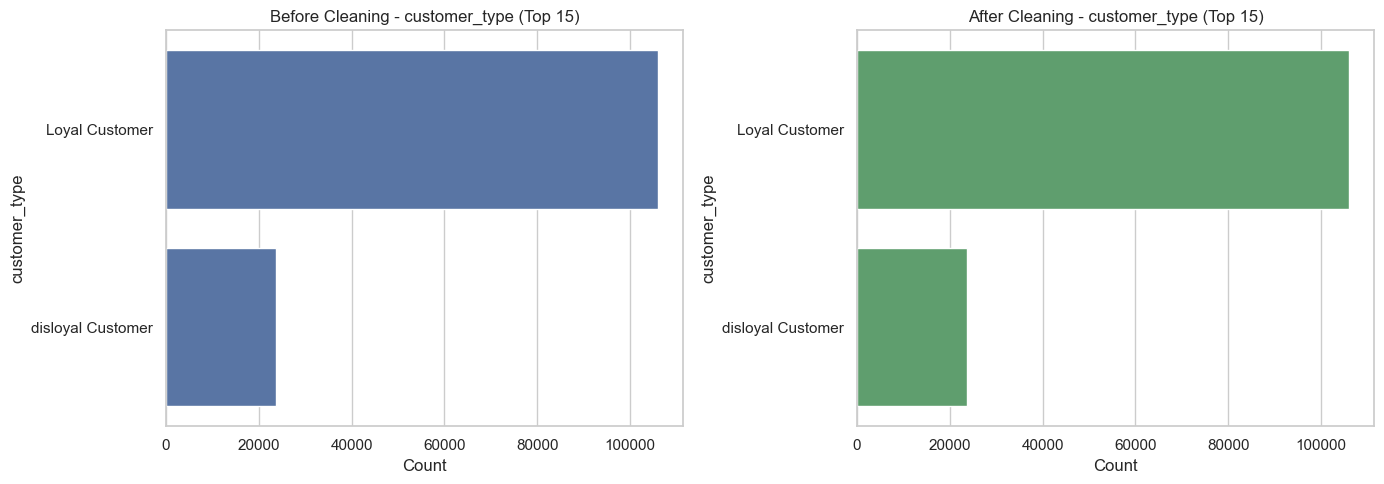

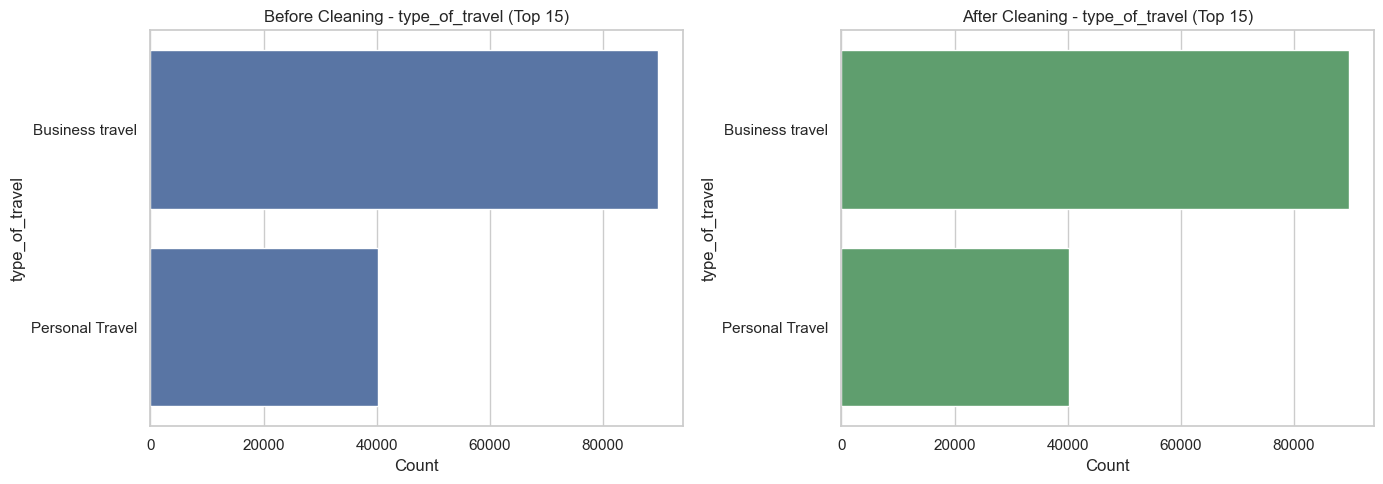

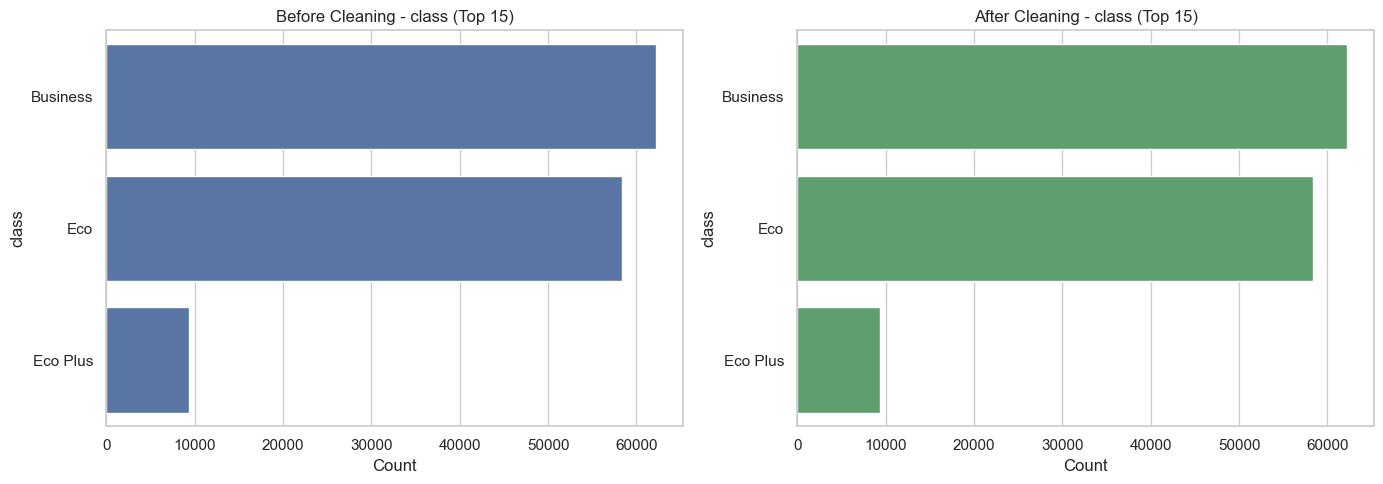

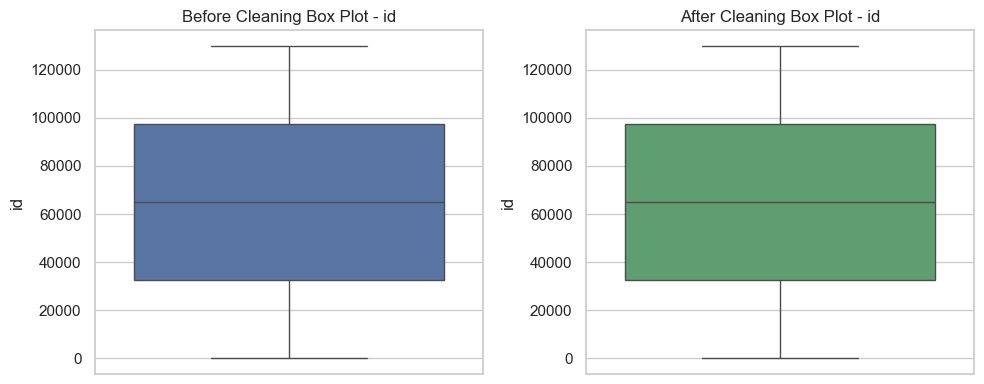

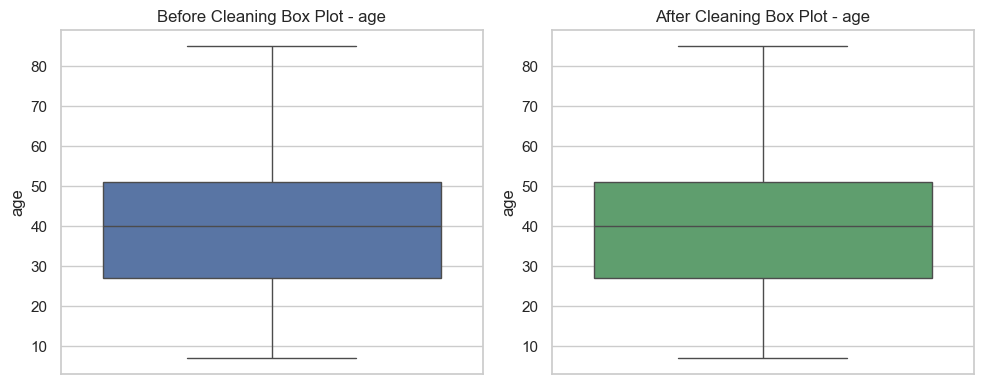

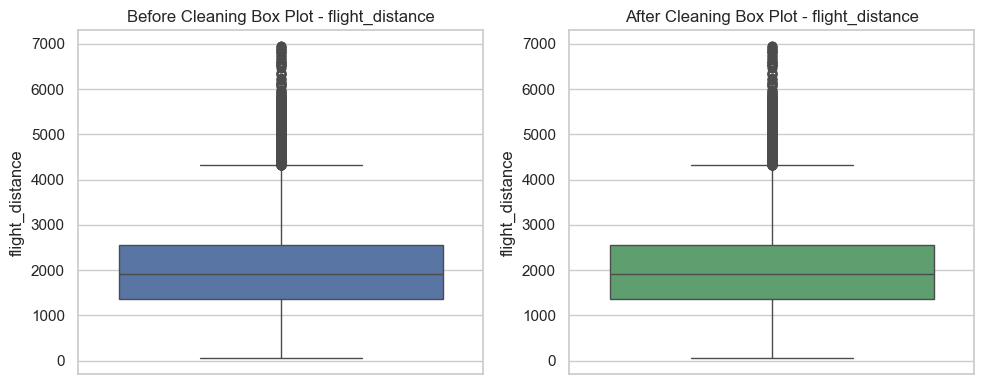

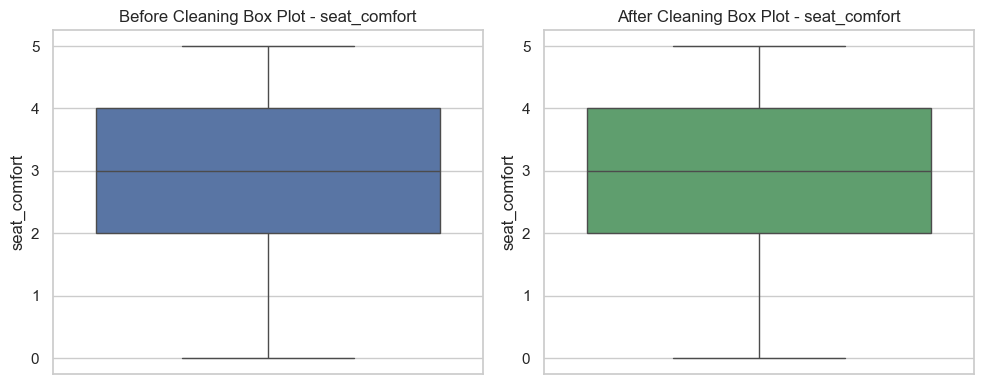

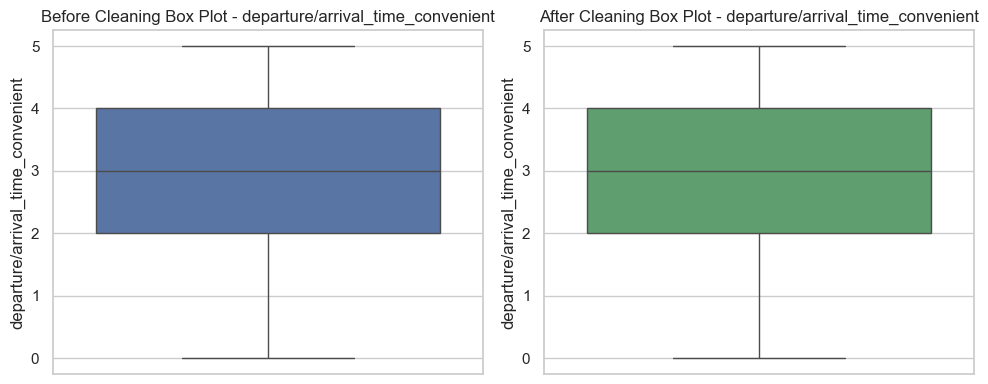

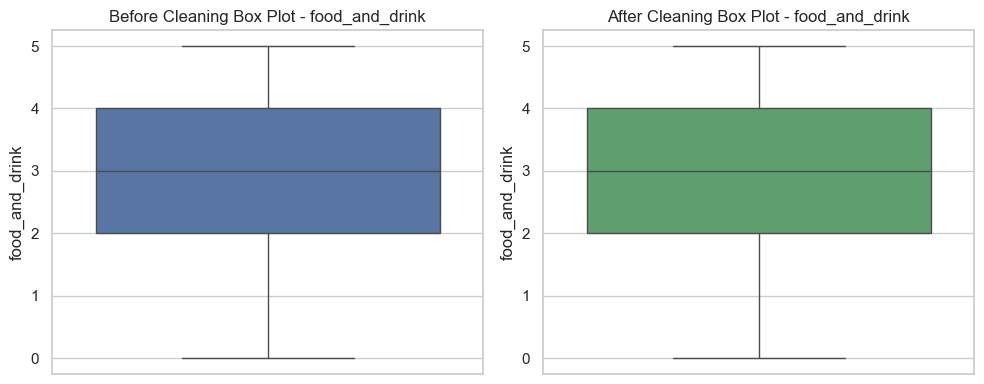

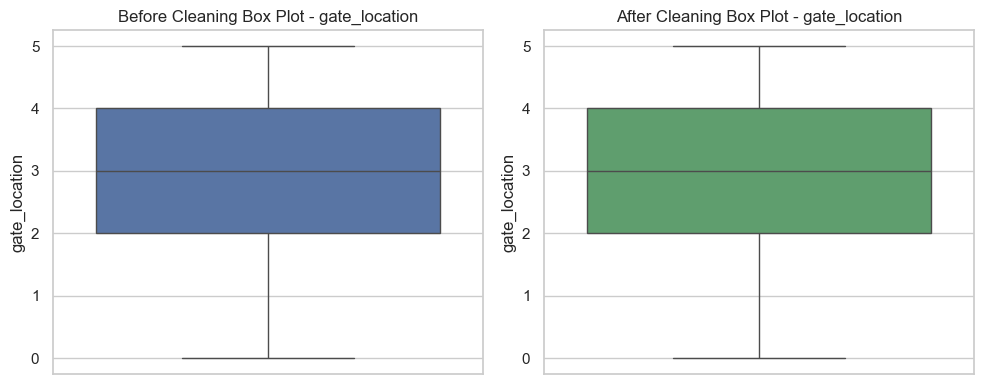

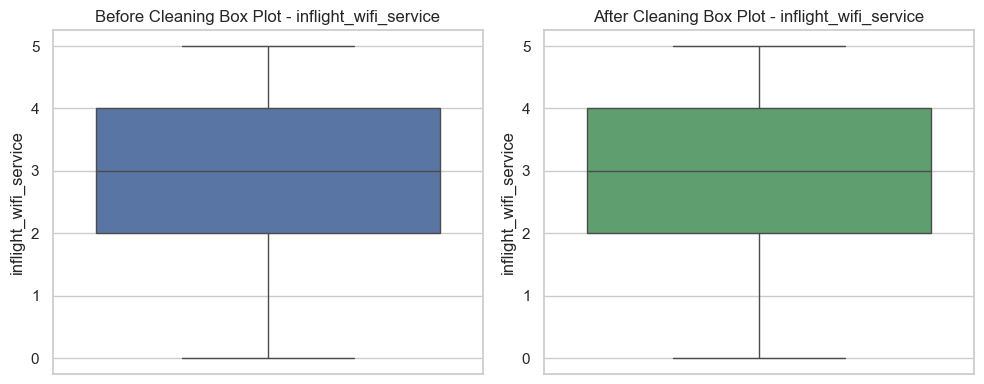

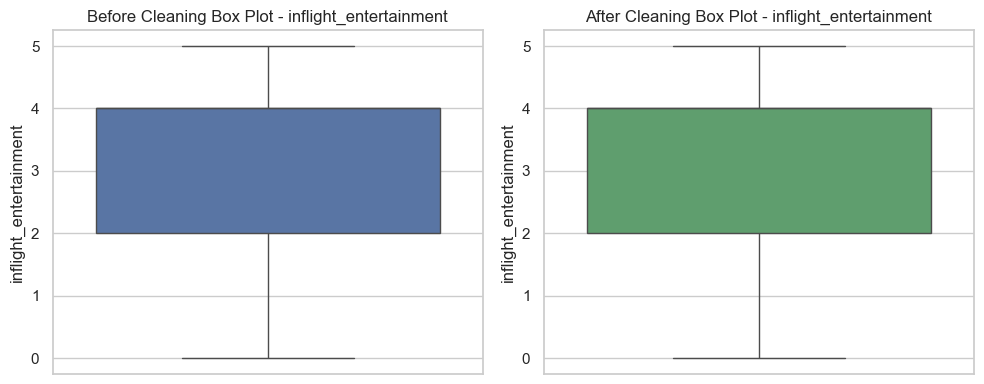

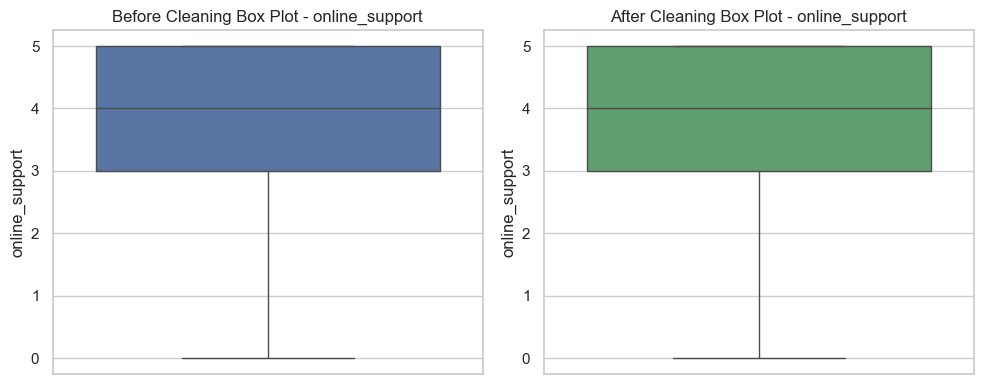

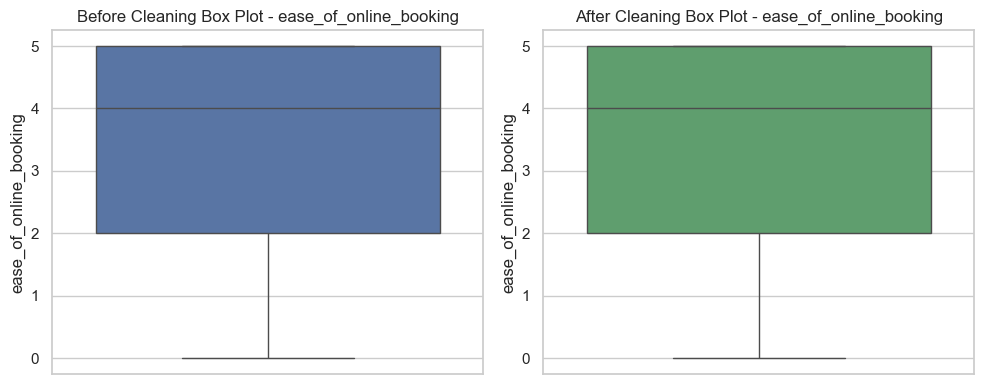

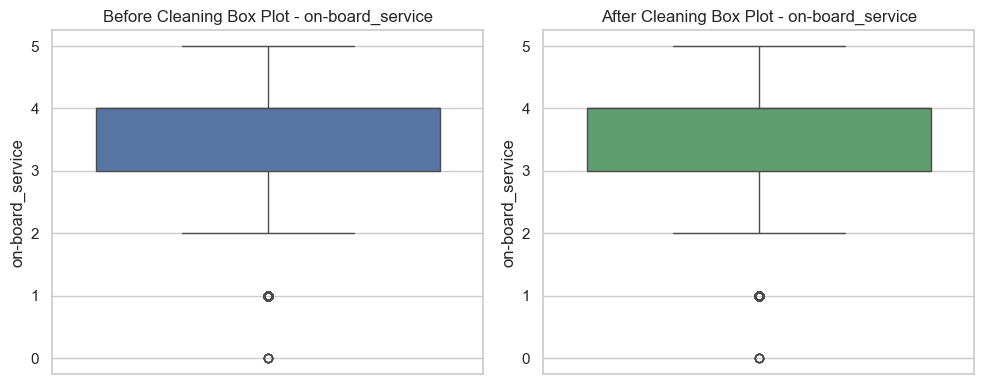

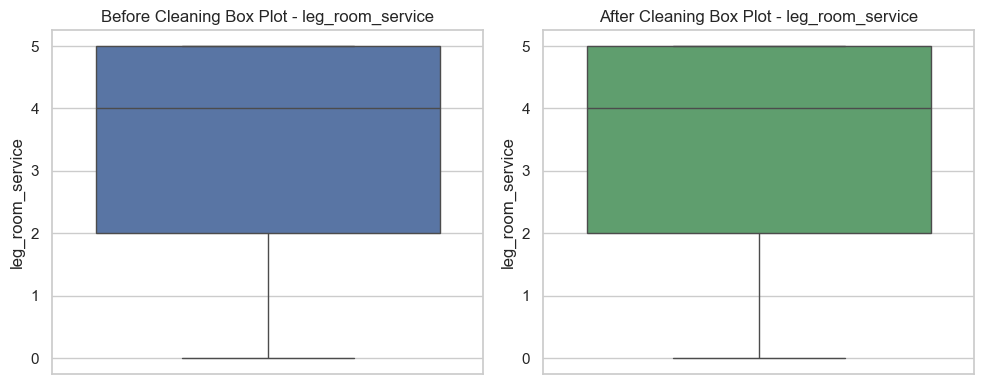

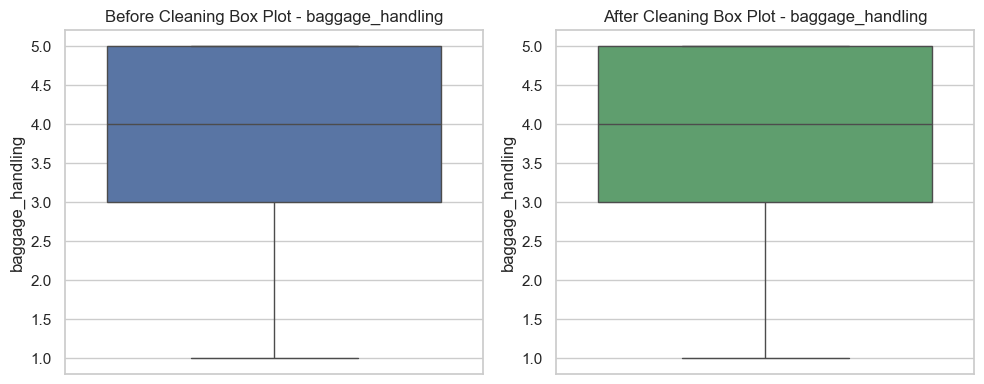

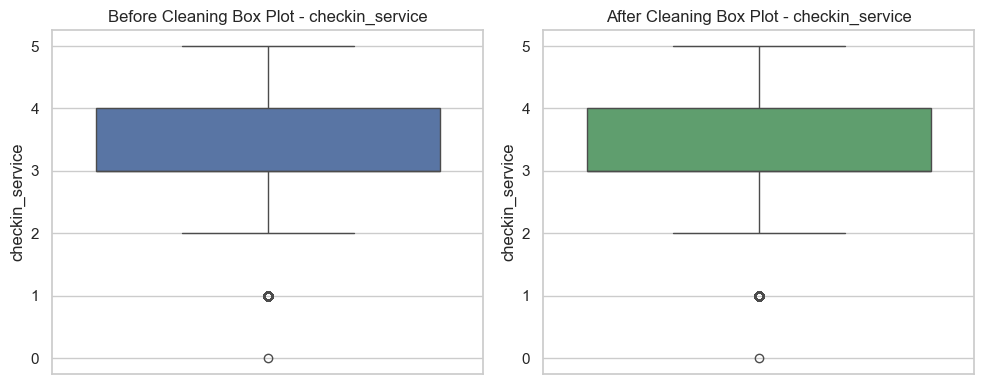

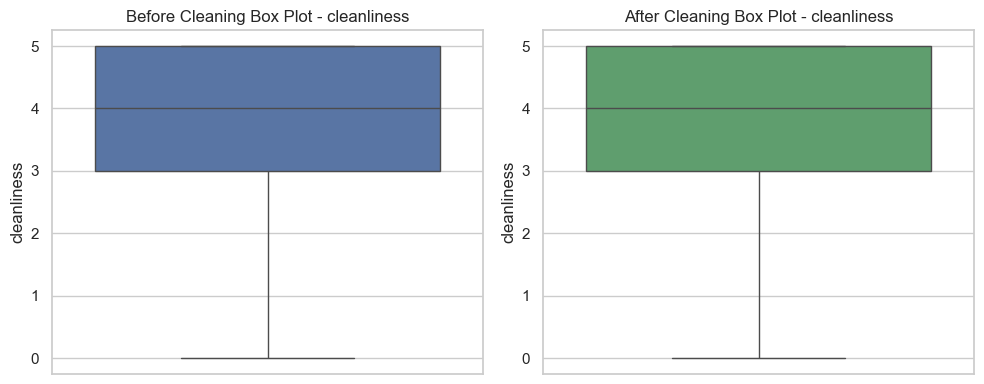

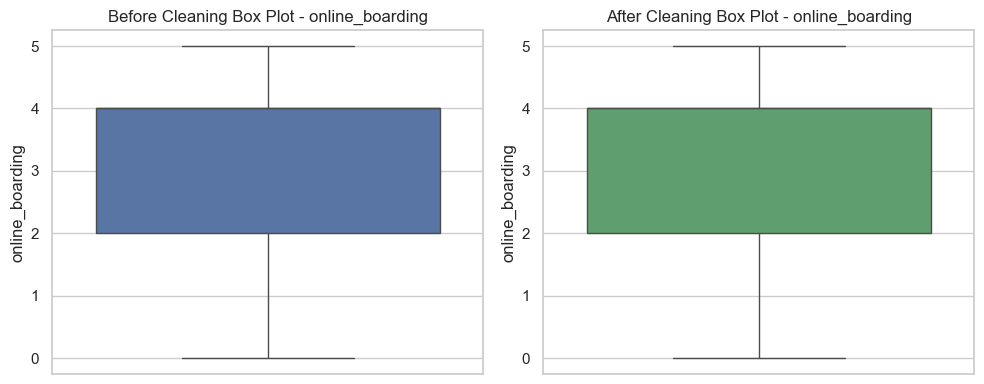

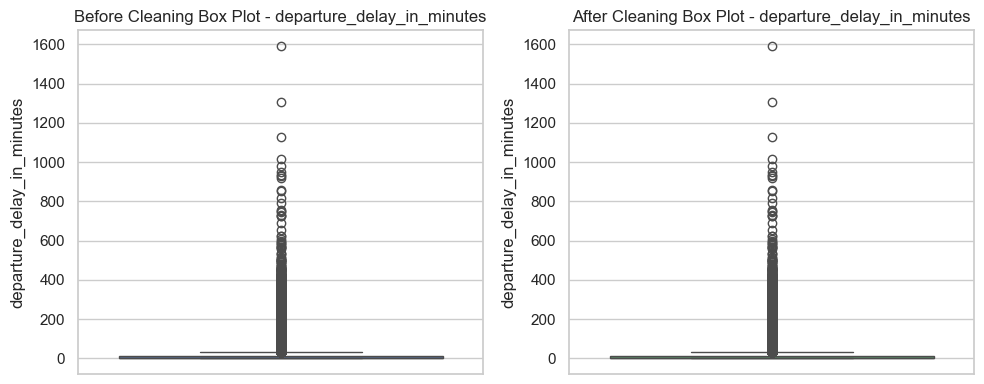

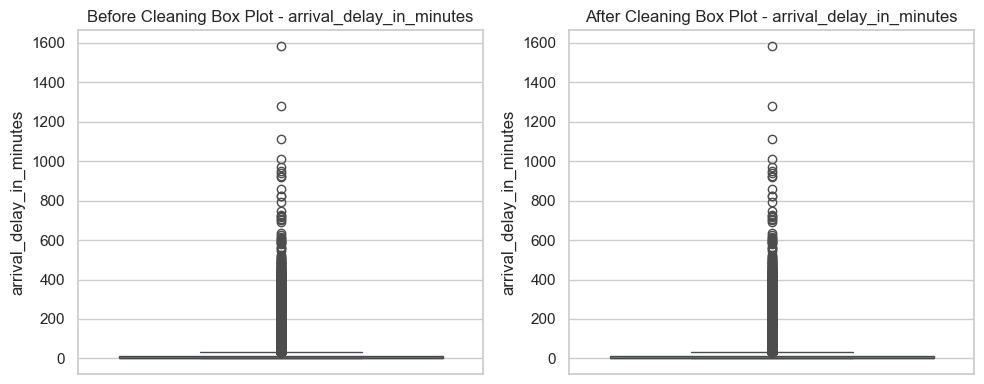

In [34]:
# Before vs After Cleaning: Distributions + Box Plots (all columns)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load data (edit filenames if your raw/clean names differ)
raw_path = "satisfaction.xlsx"  # before cleaning
clean_path = "passenger_satisfaction_cleaned.csv"  # after cleaning

df_before = pd.read_excel(raw_path)
df_after = pd.read_csv(clean_path)

# Normalize column names for matching

def normalize_col(c):
    return str(c).strip().lower().replace(" ", "_")

df_before = df_before.rename(columns={c: normalize_col(c) for c in df_before.columns})
df_after = df_after.rename(columns={c: normalize_col(c) for c in df_after.columns})

common_cols = [c for c in df_before.columns if c in df_after.columns]
print(f"Common columns to compare: {len(common_cols)}")

num_cols = [c for c in common_cols if pd.api.types.is_numeric_dtype(df_before[c]) and pd.api.types.is_numeric_dtype(df_after[c])]
cat_cols = [c for c in common_cols if c not in num_cols]

# 1) Distributions for each numeric column (before vs after)
# Make service ratings use consistent bar widths, and make delay columns easier to see.
service_rating_cols = [
    c for c in num_cols
    if ("service" in c) or ("comfort" in c) or ("cleanliness" in c)
]

delay_cols = {"arrival_delay_in_minutes", "departure_delay_in_minutes"}

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    before_vals = df_before[col].dropna()
    after_vals = df_after[col].dropna()

    if col in service_rating_cols:
        # Ratings are typically discrete integers; keep bar width consistent at 1.
        max_val = int(max(before_vals.max(), after_vals.max())) if len(before_vals) and len(after_vals) else 5
        bins = np.arange(-0.5, max_val + 1.5, 1)

        sns.histplot(before_vals, bins=bins, kde=False, ax=axes[0], color="#4C72B0")
        sns.histplot(after_vals, bins=bins, kde=False, ax=axes[1], color="#55A868")

        axes[0].set_xticks(range(0, max_val + 1))
        axes[1].set_xticks(range(0, max_val + 1))

    elif col in delay_cols:
        # Long-tail delays can flatten bars; trim display to 99th percentile for readability.
        b_hi = before_vals.quantile(0.99) if len(before_vals) else 0
        a_hi = after_vals.quantile(0.99) if len(after_vals) else 0
        hi = max(b_hi, a_hi)

        before_plot = before_vals[before_vals <= hi] if hi > 0 else before_vals
        after_plot = after_vals[after_vals <= hi] if hi > 0 else after_vals

        sns.histplot(before_plot, bins=40, kde=False, ax=axes[0], color="#4C72B0")
        sns.histplot(after_plot, bins=40, kde=False, ax=axes[1], color="#55A868")

        axes[0].set_xlim(left=0)
        axes[1].set_xlim(left=0)

    else:
        sns.histplot(before_vals, bins=30, kde=False, ax=axes[0], color="#4C72B0")
        sns.histplot(after_vals, bins=30, kde=False, ax=axes[1], color="#55A868")

    axes[0].set_title(f"Before Cleaning - {col}")
    axes[0].set_xlabel(col)

    axes[1].set_title(f"After Cleaning - {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

# 2) Distributions for each categorical column (before vs after)
for col in cat_cols:
    # top categories to keep charts readable
    before_counts = df_before[col].astype(str).value_counts(dropna=False).head(15)
    after_counts = df_after[col].astype(str).value_counts(dropna=False).head(15)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=before_counts.values, y=before_counts.index, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Before Cleaning - {col} (Top 15)")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel(col)

    sns.barplot(x=after_counts.values, y=after_counts.index, ax=axes[1], color="#55A868")
    axes[1].set_title(f"After Cleaning - {col} (Top 15)")
    axes[1].set_xlabel("Count")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

# 3) Box plots for numeric columns (before vs after)
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.boxplot(y=df_before[col], ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"Before Cleaning Box Plot - {col}")
    axes[0].set_ylabel(col)

    sns.boxplot(y=df_after[col], ax=axes[1], color="#55A868")
    axes[1].set_title(f"After Cleaning Box Plot - {col}")
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()




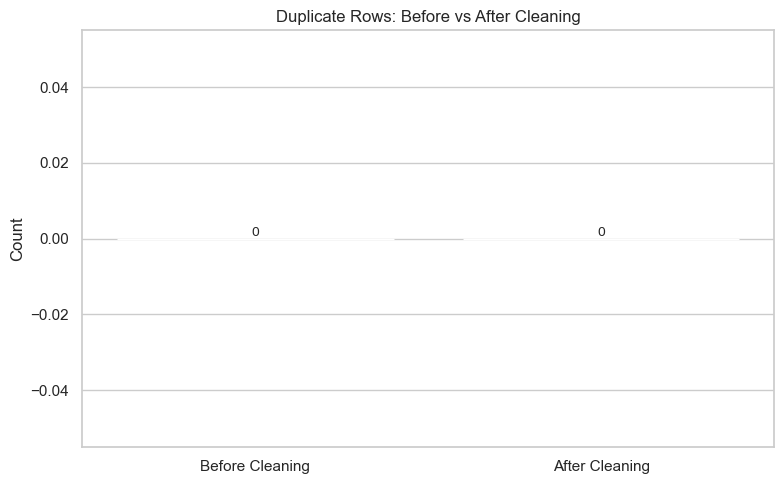

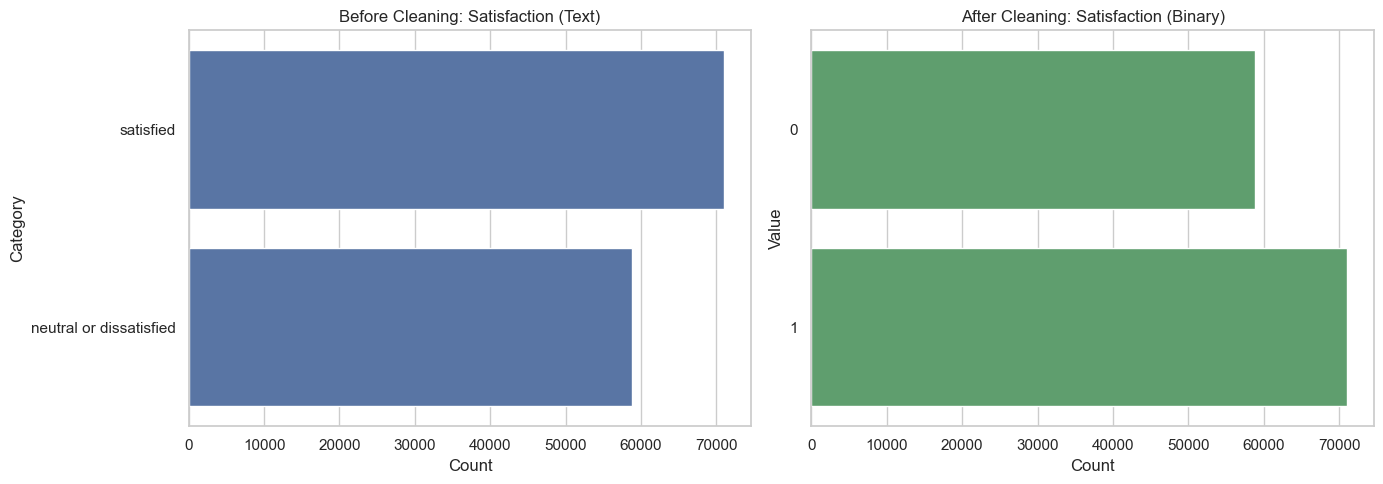

In [37]:
# Extra visuals: duplicate removal + satisfaction text-to-binary conversion
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load source and cleaned data
raw_path = "satisfaction.xlsx"
clean_path = "passenger_satisfaction_cleaned.csv"

df_before = pd.read_excel(raw_path)
df_after = pd.read_csv(clean_path)

# Normalize column names for robust matching

def normalize_col(c):
    return str(c).strip().lower().replace(" ", "_")

df_before.columns = [normalize_col(c) for c in df_before.columns]
df_after.columns = [normalize_col(c) for c in df_after.columns]

# ---------- 1) Duplicate count before vs after ----------
dup_before = int(df_before.duplicated().sum())
dup_after = int(df_after.duplicated().sum())

dup_df = pd.DataFrame({
    "Dataset": ["Before Cleaning", "After Cleaning"],
    "Duplicate Rows": [dup_before, dup_after]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=dup_df, x="Dataset", y="Duplicate Rows", hue="Dataset", palette=["#4C72B0", "#55A868"], legend=False)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title("Duplicate Rows: Before vs After Cleaning")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ---------- 2) Satisfaction conversion: text (before) vs binary (after) ----------
sat_before_col = "satisfaction" if "satisfaction" in df_before.columns else None
sat_after_col = "satisfaction" if "satisfaction" in df_after.columns else None

if sat_before_col is None:
    cands = [c for c in df_before.columns if "satisf" in c]
    sat_before_col = cands[0] if cands else None
if sat_after_col is None:
    cands = [c for c in df_after.columns if "satisf" in c]
    sat_after_col = cands[0] if cands else None

if sat_before_col is None or sat_after_col is None:
    print("Could not find a satisfaction column in one of the datasets.")
else:
    before_counts = df_before[sat_before_col].astype(str).value_counts(dropna=False)

    after_series = df_after[sat_after_col]
    if not pd.api.types.is_numeric_dtype(after_series):
        mapped = after_series.astype(str).str.strip().str.lower().map({
            "satisfied": 1,
            "neutral or dissatisfied": 0,
            "neutral/dissatisfied": 0,
            "0": 0,
            "1": 1
        })
        after_plot_series = mapped.fillna(after_series)
    else:
        after_plot_series = after_series

    after_counts = after_plot_series.value_counts(dropna=False).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=before_counts.values, y=before_counts.index.astype(str), ax=axes[0], color="#4C72B0")
    axes[0].set_title("Before Cleaning: Satisfaction (Text)")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Category")

    sns.barplot(x=after_counts.values, y=after_counts.index.astype(str), ax=axes[1], color="#55A868")
    axes[1].set_title("After Cleaning: Satisfaction (Binary)")
    axes[1].set_xlabel("Count")
    axes[1].set_ylabel("Value")

    plt.tight_layout()
    plt.show()